# 1. Bradley-Terry Model with Home Court Advantage

### Imports

In [1]:
import pandas as pd
import numpy as np
import json
from typing import Dict, List, Tuple, Optional
from datetime import datetime

import choix
from scipy.special import expit
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, average_precision_score,brier_score_loss, precision_recall_fscore_support, confusion_matrix, precision_score, ConfusionMatrixDisplay,f1_score,recall_score
import seaborn as sns
from scipy.stats import norm
from scipy.stats import beta as beta_dist
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from skopt import gp_minimize
from skopt.plots import plot_convergence, plot_objective
from skopt.space import Real
from skopt.utils import use_named_args
import plotly.express as px
import plotly.graph_objects as go

### Bradley–Terry Model with HCA & Covariates

In [41]:
class BTWithCovariates:
    def __init__(
        self,
        teams, team_to_idx,
        s, beta,
        feature_cols, mu, sd,
        context_cols=None, gamma=None,
        mu_context=None, sd_context=None,
        lambda_s=1e-3, lambda_b=1e-3, lambda_g=1e-3,
        threshold=0.5,alpha_hca=None
    ):
        # --- core team parameters ---
        self.teams = list(teams)
        self.team_to_idx = dict(team_to_idx)
        self.s = np.array(s, dtype=float)
        self.s -= self.s.mean()  # mean‑centering for identifiability
        self.alpha_hca = 0.1 if alpha_hca is None else float(alpha_hca)

        # --- feature-related parameters X@beta ---
        self.feature_cols = list(feature_cols)
        self.beta = np.array(beta, dtype=float)
        self.mu = np.array(mu, dtype=float)
        self.sd = np.array(sd, dtype=float)
        self.sd[self.sd == 0] = 1.0

        # --- contextual HCA parameters Z@gamma ---
        self.context_cols = list(context_cols) if context_cols else []
        self.gamma = (
            np.random.normal(0, 0.01, len(self.context_cols))
            if gamma is None
            else np.array(gamma, dtype=float)
        )
        self.mu_context = (
            np.zeros(len(self.context_cols))
            if mu_context is None
            else np.array(mu_context, dtype=float)
        )
        self.sd_context = (
            np.ones(len(self.context_cols))
            if sd_context is None
            else np.array(sd_context, dtype=float)
        )
        self.sd_context[self.sd_context == 0] = 1.0

        # learning configuration
        self.lambda_s, self.lambda_b, self.lambda_g = lambda_s, lambda_b, lambda_g
        self.threshold = threshold

    # ---------------- Properties ----------------
    @property
    def m(self): return len(self.teams)
    @property
    def p(self): return len(self.feature_cols)
    @property
    def q(self): return len(self.context_cols)

    # ---------------- Utilities ----------------
    def _ensure_teams(self, df: pd.DataFrame):
        """Ensure unseen teams get added dynamically."""
        unseen = [t for t in pd.unique(df[["home_abbr", "away_abbr"]].values.ravel())
                  if t not in self.team_to_idx]
        if not unseen:
            return
        start = len(self.teams)
        for k, t in enumerate(unseen):
            self.team_to_idx[t] = start + k
        self.teams.extend(unseen)
        # Expand s for new teams (neutral start)
        self.s = np.concatenate([self.s, np.zeros(len(unseen))])
        self.s -= self.s.mean()

    def _standardize(self, arr, mu, sd):
        return (arr - mu) / (sd if sd != 0 else 1.0)

    def _standardize_features(self, frame):
        if self.p == 0:
            return np.zeros((len(frame), 0))
        X = np.zeros((len(frame), self.p))
        for j, col in enumerate(self.feature_cols):
            X[:, j] = self._standardize(frame[col].astype(float).values, self.mu[j], self.sd[j])
        return X

    def _standardize_context(self, frame):
        if self.q == 0:
            return np.zeros((len(frame), 0))
        Z = np.zeros((len(frame), self.q))
        for j, col in enumerate(self.context_cols):
            Z[:, j] = self._standardize(
                frame[col].astype(float).values, self.mu_context[j], self.sd_context[j]
            )
        return Z

    # ---------------- Prediction ----------------
    def predict_proba(self, frame: pd.DataFrame) -> np.ndarray:
        sh = np.array([self.s[self.team_to_idx.get(t, -1)] for t in frame["home_abbr"]])
        sa = np.array([self.s[self.team_to_idx.get(t, -1)] for t in frame["away_abbr"]])

        z = (sh - sa) + self.alpha_hca

        if self.q:
            Z = self._standardize_context(frame)
            z += Z @ self.gamma
        if self.p:
            X = self._standardize_features(frame)
            z += X @ self.beta

        # apply sigmoid
        p = 1.0 / (1.0 + np.exp(-z))
        return p

    def predict_class(self, frame: pd.DataFrame, threshold=None) -> np.ndarray:
        threshold = self.threshold if threshold is None else threshold
        return (self.predict_proba(frame) >= threshold).astype(int)

    # ---------------- Evaluation ----------------
    def evaluate(self, frame: pd.DataFrame, threshold=None):
        threshold = self.threshold if threshold is None else threshold
        p = self.predict_proba(frame)
        y_true = frame["home_win"].astype(int).values
        yhat = (p >= threshold).astype(int)
        acc = (yhat == y_true).mean()
        logloss = -(y_true * np.log(p + 1e-12)
                    + (1 - y_true) * np.log(1 - p + 1e-12)).mean()
        return acc, logloss


    def _mm_update_s(self, home_idx, away_idx, y, X, Z, beta, gamma, mm_iter=5):
            """Perform MM updates for team strengths s while holding beta,gamma fixed."""
            m = self.m
            s = self.s.copy()
            for _ in range(mm_iter):
                exp_s = np.exp(s)
                num = np.zeros(m)
                denom = np.zeros(m)

                for i in range(len(y)):
                    h, a = home_idx[i], away_idx[i]
                    eta = self.alpha_hca
                    if X.shape[1]:
                        eta += X[i] @ beta
                    if Z.shape[1]:
                        eta += Z[i] @ gamma
                    p_hat = 1.0 / (1.0 + np.exp(-(s[h] - s[a] + eta)))

                    # Accumulate numerators/denominators
                    num[h] += y[i]
                    num[a] += 1.0 - y[i]
                    denom[h] += p_hat
                    denom[a] += 1.0 - p_hat

                s = np.log((num + 1e-12) / (denom + 1e-12))
                s -= s.mean()   # identifiability
            return s

    def fit(self, df, split_col=None, split_value=None,
            valid_frame=None, test_frame=None, max_iter=1000,
            mm_iter=5, verbose=1):

        data = df if split_col is None else df[df[split_col] == split_value]
        if len(data) == 0:
            raise ValueError("Empty training data.")

        self._ensure_teams(data)

        home_idx = np.array([self.team_to_idx[t] for t in data["home_abbr"]], int)
        away_idx = np.array([self.team_to_idx[t] for t in data["away_abbr"]], int)
        y = data["home_win"].astype(float).values
        X = self._standardize_features(data)
        Z = self._standardize_context(data)
        m, p, q = self.m, self.p, self.q

        # ---------- Step 1: MM update for s (given current beta,gamma) ----------
        if verbose:
            print(f"Running {mm_iter} MM iterations for initial team strength update...")
        self.s = self._mm_update_s(home_idx, away_idx, y, X, Z,
                                   self.beta.copy(), self.gamma.copy(),
                                   mm_iter=mm_iter)

        # ---------- Step 2: Define joint objective for L‑BFGS ----------
        def objective(x):
            s = x[:m]; b = x[m:m+p]; g = x[m+p:m+p+q]; a = x[-1]
            z = (s[home_idx] - s[away_idx]) + a
            if p: z += X @ b
            if q: z += Z @ g
            p_hat = 1 / (1 + np.exp(-z))
            nll = -np.sum(y * np.log(p_hat + 1e-12) +
                          (1 - y) * np.log(1 - p_hat + 1e-12))
            reg = 0.5 * (self.lambda_s*np.sum(s**2)
                         + self.lambda_b*np.sum(b**2)
                         + self.lambda_g*np.sum(g**2)
                         + self.lambda_s * a**2)
            loss = nll + reg

            err = y - p_hat
            grad_s = np.zeros_like(s)
            np.add.at(grad_s, home_idx, -err)
            np.add.at(grad_s, away_idx, err)
            grad_b = -(X.T @ err) if p else np.zeros(0)
            grad_g = -(Z.T @ err) if q else np.zeros(0)
            grad_a = -np.sum(err) + 1e-4*a
            grad = np.concatenate([grad_s, grad_b, grad_g, [grad_a]])
            return loss, grad

        # ---------- Step 3: History tracking ----------
        history = {"iter": [], "train_acc": [], "train_logloss": [],
                   "test_acc": [],  "test_logloss": []}

        def callback(xk):
            if verbose is None:
                return
            it = len(history["iter"])
            if it % verbose == 0:
                self.s = xk[:m] - np.mean(xk[:m])
                self.beta = xk[m:m+p]
                self.gamma = xk[m+p:m+p+q]
                self.alpha_hca = xk[-1]
                tr_acc, tr_ll = self.evaluate(data)
                te_acc, te_ll = (np.nan, np.nan)
                if test_frame is not None:
                    te_acc, te_ll = self.evaluate(test_frame)
                history["iter"].append(it)
                history["train_acc"].append(tr_acc)
                history["train_logloss"].append(tr_ll)
                history["test_acc"].append(te_acc)
                history["test_logloss"].append(te_ll)
                print(f"[{it:04d}] Train acc={tr_acc:.4f} ll={tr_ll:.4f} | "
                      f"Test acc={te_acc:.4f} ll={te_ll:.4f}")

        # ---------- L‑BFGS Optimization ----------
        x0 = np.concatenate([self.s, self.beta, self.gamma, [self.alpha_hca]])
        res = minimize(
            objective, x0, jac=True, method="L-BFGS-B",
            callback=callback,
            options={"disp": True, "maxiter": max_iter}
        )

        # ---------- Post‑process ----------
        opt = res.x
        self.s = opt[:m]
        self.beta = opt[m:m+p]
        self.gamma = opt[m+p:m+p+q]
        self.alpha_hca = opt[-1]
        self.s -= self.s.mean()

        tr_acc, tr_ll = self.evaluate(data)
        te_acc, te_ll = (np.nan, np.nan)
        if test_frame is not None:
            te_acc, te_ll = self.evaluate(test_frame)

        history["iter"].append(len(history["iter"]))
        history["train_acc"].append(tr_acc)
        history["train_logloss"].append(tr_ll)
        history["test_acc"].append(te_acc)
        history["test_logloss"].append(te_ll)

        avg_theta = np.exp(self.alpha_hca)
        print(f"Estimated global home‑court multiplier θ̄ = {avg_theta:.4f}")
        if verbose:
            print(f"Final: Train acc={tr_acc:.4f}, logloss={tr_ll:.4f}")

        return {"opt_result": res, "history": history}

    def evaluate_by_game_type(self, frame: pd.DataFrame, game_col="Game type", threshold=None):
        """
        Evaluate model performance separately for each game type (e.g., regular, playoff, playin).
        Returns a dictionary of metrics keyed by game type.
        """
        if game_col not in frame.columns:
            raise ValueError(f"Column '{game_col}' not found in dataframe.")

        game_types = sorted(frame[game_col].dropna().unique())
        results = {}

        print("\n=== Performance by Game Type ===")
        for gtype in game_types:
            subset = frame[frame[game_col] == gtype]
            if len(subset) == 0:
                continue
            acc, logloss = self.evaluate(subset, threshold=threshold)
            results[gtype] = {"accuracy": acc, "logloss": logloss}
            print(f"{gtype:<10} | acc={acc:.4f} | logloss={logloss:.4f} | n={len(subset)}")

        avg_acc = np.mean([v["accuracy"] for v in results.values()])
        avg_ll  = np.mean([v["logloss"] for v in results.values()])
        print(f"---------------------------------")
        print(f"Average   | acc={avg_acc:.4f} | logloss={avg_ll:.4f}")
        print("=================================\n")

        return results

### Load and Save Model

In [4]:
def save_model(
    model,
    path_npz: str,
    path_json: Optional[str] = None,
    extra_meta: Optional[Dict] = None,
):
    """
    Save a trained BTWithCovariates model to a compressed .npz file.
    Optionally dump a human-readable JSON alongside it.

    Parameters
    ----------
    model : BTWithCovariates
        Trained model instance.
    path_npz : str
        Path to the output compressed NumPy file (.npz).
    path_json : str, optional
        Path to a JSON file for human-readable parameters.
    extra_meta : dict, optional
        Extra information to store in metadata.
    """
    # --- Prepare metadata ---
    meta = {
        "feature_cols": model.feature_cols,
        "teams": model.teams,
        "extra_meta": extra_meta or {},
        "class_name": model.__class__.__name__,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "optimizer_settings": {
            "lambda_s": model.lambda_s, "lambda_b": model.lambda_b,"threshold": model.threshold,
        },
    }

    # --- Save the model core parameters ---
    np.savez_compressed(
        path_npz,
        s=np.array(model.s, dtype=float),
        beta=np.array(model.beta, dtype=float),
        mu=np.array(model.mu, dtype=float),
        sd=np.array(model.sd, dtype=float),
        teams=np.array(model.teams, dtype=object),
        t2i_keys=np.array(list(model.team_to_idx.keys()), dtype=object),
        t2i_vals=np.array(list(model.team_to_idx.values()), dtype=int),
        gamma=np.array(getattr(model, "gamma", []), dtype=float),
        mu_context=np.array(getattr(model, "mu_context", []), dtype=float),
        sd_context=np.array(getattr(model, "sd_context", []), dtype=float),
        context_cols=np.array(getattr(model, "context_cols", []), dtype=object),
        meta_json=np.bytes_(json.dumps(meta)),
    )

    # --- Optional JSON dump for readability ---
    if path_json:
        payload = {
            "s": model.s.tolist(),
            "beta": model.beta.tolist(),
            "mu": np.array(model.mu).tolist(),
            "sd": np.array(model.sd).tolist(),
            "teams": model.teams,
            "team_to_idx": model.team_to_idx,
            "extra_meta": meta["extra_meta"],
            "optimizer_settings": meta["optimizer_settings"],
            "timestamp": meta["timestamp"],
        }
        with open(path_json, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
        print(f"Model parameters saved to {path_json}")

    print(f"Model saved successfully to {path_npz}")

def load_model(path_npz: str) -> BTWithCovariates:
    """
    Load a saved BTWithCovariates model (.npz) and reconstruct it
    ready for predictions or continued training on a new dataset.
    """
    # --- Load the compressed file ---
    blob = np.load(path_npz, allow_pickle=True)

    # --- Basic parameters ---
    s = blob["s"].astype(float)

    beta = blob["beta"].astype(float)
    mu = blob["mu"].astype(float)
    sd = blob["sd"].astype(float)
    teams = list(blob["teams"])
    t2i_keys = list(blob["t2i_keys"])
    t2i_vals = list(blob["t2i_vals"])
    team_to_idx = {k: int(v) for k, v in zip(t2i_keys, t2i_vals)}

    # --- Retrieve metadata ---
    meta_raw = blob["meta_json"].tobytes().decode("utf-8")
    meta = json.loads(meta_raw)
    feature_cols = meta.get("feature_cols", [])
    optimizer_settings = meta.get("optimizer_settings", {})

    # --- Restore training hyperparameters safely ---
    lambda_s = float(optimizer_settings.get("lambda_s", 0.002))
    lambda_b = float(optimizer_settings.get("lambda_b", 0.01))
    threshold = float(optimizer_settings.get("threshold", 0.5))
    decay_every = optimizer_settings.get("decay_every", None)
    decay_factor = optimizer_settings.get("decay_factor", None)
    gamma = blob.get("gamma")
    if gamma is not None: gamma = gamma.astype(float)
    mu_context = blob.get("mu_context")
    if mu_context is not None: mu_context = mu_context.astype(float)
    sd_context = blob.get("sd_context")
    if sd_context is not None: sd_context = sd_context.astype(float)
    context_cols = list(blob.get("context_cols", []))

    # --- Recreate model instance ---
    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s,
        beta=beta,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=lambda_s,
        lambda_b=lambda_b,
        threshold=threshold,
        gamma=gamma,
        context_cols=context_cols,
        mu_context=mu_context,
        sd_context=sd_context,
    )

    print(f"Model loaded successfully from {path_npz}")
    print(f"Teams: {len(teams)} | Features: {len(feature_cols)}")

    return model

### 1.2 Load Data & Initialization

In [42]:
df = pd.read_csv('./data/bt_final_cleaned.csv')
context_cols = ["home_b2b", "away_b2b","home_rest_days", "away_rest_days", "rest_diff"]
feature_cols = ["diff_recent_margin","diff_recent_win_pct","diff_pts_pg_to_date","split_win_pct_delta"]

train=df[df["split"]=="train"].copy()
test=df[df["split"]=="test"].copy()


### 1.3 Build Train Tensors

In [44]:
# Extract indices
teams = sorted(pd.unique(pd.concat([train["home_abbr"], train["away_abbr"]], ignore_index=True)))
team_to_idx = {t: i for i, t in enumerate(teams)}
m = len(teams)

home_idx = np.array([team_to_idx[t] for t in train["home_abbr"]], dtype=int)
away_idx = np.array([team_to_idx[t] for t in train["away_abbr"]], dtype=int)
y = train["home_win"].astype(float).values
n = len(y)

# Standardize regular feature columns (X)
if feature_cols:
    X_raw = train[feature_cols].astype(float).values
    mu = X_raw.mean(axis=0)
    sd = X_raw.std(axis=0)
    sd[sd == 0] = 1.0
    X = (X_raw - mu) / sd
else:
    X = np.zeros((n, 0))
    mu = np.array([])
    sd = np.array([])
p = X.shape[1]

# Standardize contextual columns (Z)
if context_cols:
    Z_raw = train[context_cols].astype(float).values
    mu_context = Z_raw.mean(axis=0)
    sd_context = Z_raw.std(axis=0)
    sd_context[sd_context == 0] = 1.0
    Z = (Z_raw - mu_context) / sd_context
else:
    Z = np.zeros((n, 0))
    mu_context = np.array([])
    sd_context = np.array([])
q = Z.shape[1]

In [45]:
s_init     = np.zeros(len(teams))
beta_init  = np.zeros(len(feature_cols))
gamma_init = np.zeros(len(context_cols))

## 1.A Train and Test

### 1.4 Model Fitting

In [46]:
# After creating df with split in {"train","test","valid"} and computing mu/sd on TRAIN
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu, sd=sd,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context,
    lambda_s=1e-3, lambda_b=1e-3, lambda_g=1e-3
)

result = model.fit(
    df,
    split_col="split",
    split_value="train",
    max_iter=10000,
    test_frame=test,
    verbose=1
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6229 ll=0.6498
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6333 ll=0.6482
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6335 ll=0.6483
[0003] Train acc=0.6571 ll=0.6192 | Test acc=0.6376 ll=0.6475
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6368 ll=0.6475
[0005] Train acc=0.6561 ll=0.6182 | Test acc=0.6335 ll=0.6485
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6348 ll=0.6488
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6333 ll=0.6494
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6323 ll=0.6496
[0009] Train acc=0.6573 ll=0.6178 | Test acc=0.6315 ll=0.6499
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6325 ll=0.6500
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6320 ll=0.6501
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6315 ll=0.6500
[0013] Train acc=0.6561 ll=0.6178 | Test acc=0.6315 ll=0.6501
[0014] Train acc=0.6560 ll=0.6178 | Test acc=0.6328 ll=0.6501
[0015] Tra

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


### 1.5 Result Evaluation

In [47]:
def evaluate_metrics(model, frame, threshold=0.5, eps=1e-12):
    y_true = frame["home_win"].astype(int).values
    p = model.predict_proba(frame)

    # Core metrics
    acc = accuracy_score(y_true, (p >= threshold).astype(int))
    ll = log_loss(y_true, np.clip(p, eps, 1 - eps))
    brier = brier_score_loss(y_true, p)

    # Ranking metrics (guard against edge cases)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    ap = average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan

    # Threshold metrics
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, (p >= threshold).astype(int), average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, (p >= threshold).astype(int)).ravel()

    return {
        "n": int(len(y_true)),
        "accuracy": float(acc),
        "log_loss": float(ll),
        "brier": float(brier),
        "roc_auc": float(auc),
        "avg_precision": float(ap),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

In [48]:
train_metrics = evaluate_metrics(model, train)
test_metrics  = evaluate_metrics(model, test)

print("Train metrics:")
for k, v in train_metrics.items():
    print(f"  {k}: {v}")

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

Train metrics:
  n: 8874
  accuracy: 0.6560739238224025
  log_loss: 0.6178040866963985
  brier: 0.21440789290568568
  roc_auc: 0.7032041110447935
  avg_precision: 0.7492503905414107
  precision: 0.6738763095640419
  recall: 0.7804305283757339
  f1: 0.7232499093217265
  tn: 1834
  fp: 1930
  fn: 1122
  tp: 3988
Test metrics:
  n: 3962
  accuracy: 0.6320040383644624
  log_loss: 0.6501687786071022
  brier: 0.22858556595230328
  roc_auc: 0.6612838210761971
  avg_precision: 0.6929552709605125
  precision: 0.6417854463615904
  recall: 0.7728093947606143
  f1: 0.7012295081967214
  tn: 793
  fp: 955
  fn: 503
  tp: 1711


### 1.6 Plots

In [49]:
hist = result["history"]

# convert arrays safely
iters     = np.array(hist["iter"], dtype=float)
train_acc = np.array(hist["train_acc"], dtype=float)
test_acc  = np.array(hist["test_acc"], dtype=float)
train_ll  = np.array(hist["train_logloss"], dtype=float)
test_ll   = np.array(hist["test_logloss"], dtype=float)

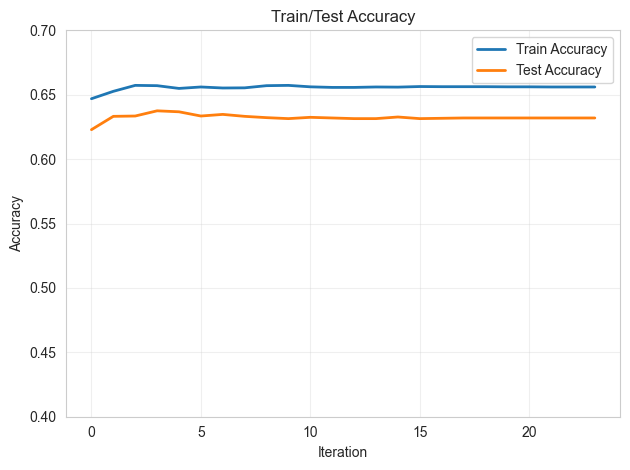

In [50]:
# --- Accuracy plot ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

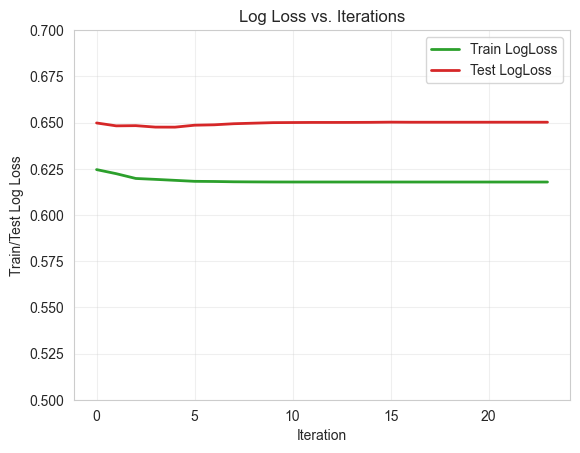

In [51]:
# Log-loss
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.5, 0.7)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [52]:
def calibration_curve_with_ci(y_true, p_pred, n_bins=10, strategy="uniform", title="Calibration Curve (Reliability Diagram)"):
    """
    Plots calibration curve with 95% binomial CIs for each bin.
    y_true: array-like of shape (n_samples,), values in {0,1}
    p_pred: array-like of predicted probabilities in [0,1]
    n_bins: number of bins
    strategy: "uniform" (equal-width in probability) or "quantile" (equal-count)
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.clip(np.asarray(p_pred), 1e-12, 1-1e-12)

    df = pd.DataFrame({"y": y_true, "p": p_pred})

    if strategy == "quantile":
        # Bin by quantiles of predicted probability (equal count)
        # Ensure unique bin edges
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(np.quantile(df["p"], quantiles))
        # If many ties shrink number of bins
        if len(edges) - 1 < n_bins:
            n_bins = len(edges) - 1
        df["bin"] = pd.cut(df["p"], bins=edges, include_lowest=True, duplicates="drop")
    elif strategy == "uniform":
        edges = np.linspace(0.0, 1.0, n_bins + 1)
        df["bin"] = pd.cut(df["p"], bins=edges, include_lowest=True)
    else:
        raise ValueError("strategy must be 'uniform' or 'quantile'")

    grp = df.groupby("bin", observed=False)
    n = grp.size().values
    if len(n) == 0:
        raise ValueError("No bins formed. Check inputs.")

    p_mean = grp["p"].mean().values
    y_mean = grp["y"].mean().values  # observed frequency
    # 95% binomial proportion CI using Wilson or Beta posterior (Jeffreys)
    # Here: Jeffreys interval via Beta(0.5,0.5) posterior for robustness in small bins.
    k = (grp["y"].sum()).values
    lower = beta_dist.ppf(0.025, k + 0.5, n - k + 0.5)
    upper = beta_dist.ppf(0.975, k + 0.5, n - k + 0.5)

    # Plot
    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect calibration")
    ax.errorbar(p_mean, y_mean, yerr=[y_mean - lower, upper - y_mean],
                fmt="o", color="#1f77b4", ecolor="#1f77b4", elinewidth=1, capsize=3, label="Bins")
    # Bin sizes as marker size
    ms = 20 * (n / n.max())
    ax.scatter(p_mean, y_mean, s=ms, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(title + f"\n(n={len(y_true)}, bins={n_bins}, strategy={strategy})")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

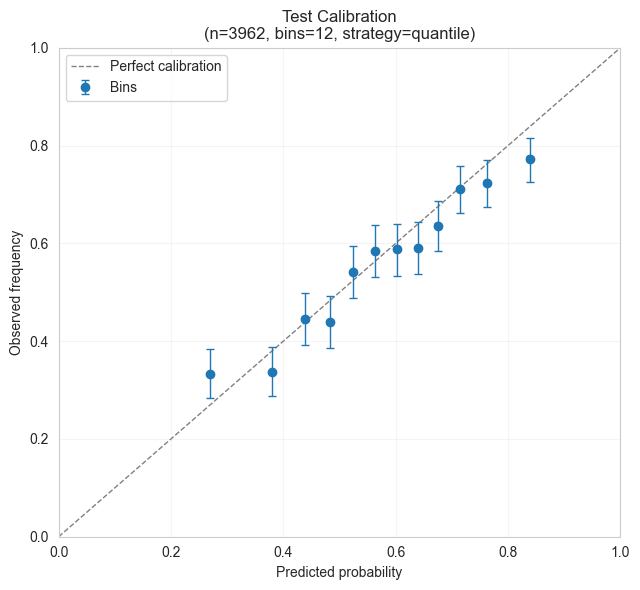

In [53]:
y_true_test = test['home_win'].astype(int).values
p_pred_test = model.predict_proba(test)
calibration_curve_with_ci(y_true_test, p_pred_test, n_bins=12, strategy="quantile", title="Test Calibration")

In [19]:
def normal_probability_plot_with_band(y_true, p_pred, n_sim=500, title="Normal Probability Plot of Standardized Residuals"):
    """
    Creates a Q–Q plot for standardized probability residuals r = (y - p) / sqrt(p(1-p)),
    with a 95% simulation band that accounts for heteroskedastic Bernoulli noise.
    The band is generated by parametric bootstrap under the fitted probabilities.
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.clip(np.asarray(p_pred), 1e-12, 1-1e-12)

    # Standardized residuals (Pearson residuals for Bernoulli)
    r = (y_true - p_pred) / np.sqrt(p_pred * (1 - p_pred))

    # Sort residuals and their theoretical normal quantiles
    r_sorted = np.sort(r)
    n = len(r_sorted)
    probs = (np.arange(1, n + 1) - 0.5) / n
    z_theory = norm.ppf(probs)

    # Simulation band: simulate y* ~ Bernoulli(p_pred), compute residuals, take order stats
    rng = np.random.default_rng(12345)
    sim_order_stats = np.empty((n_sim, n), dtype=float)
    for s in range(n_sim):
        y_sim = rng.binomial(1, p_pred)
        r_sim = (y_sim - p_pred) / np.sqrt(p_pred * (1 - p_pred))
        sim_order_stats[s, :] = np.sort(r_sim)

    lower = np.quantile(sim_order_stats, 0.025, axis=0)
    upper = np.quantile(sim_order_stats, 0.975, axis=0)

    # Plot
    fig, ax = plt.subplots(figsize=(6.8, 6.0))
    ax.fill_between(z_theory, lower, upper, color="#d3e5ff", alpha=0.8, label="95% simulation band")
    ax.plot(z_theory, r_sorted, "o", ms=3, color="#1f77b4", label="Empirical residuals")
    ax.plot([z_theory.min(), z_theory.max()], [z_theory.min(), z_theory.max()],
            "--", color="gray", lw=1, label="y=x")

    ax.set_xlabel("Theoretical quantiles N(0,1)")
    ax.set_ylabel("Ordered residuals")
    ax.set_title(title + f"\n(n={n})")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

In [20]:
normal_probability_plot_with_band(y_true_test, p_pred_test, n_sim=800, title="Test Residual Q–Q with 95% band")

NameError: name 'y_true_test' is not defined

### 1.7 Optimization

### Method 1: Grid Search (Abandoned)

In [46]:
class BTWrapper(BaseEstimator, ClassifierMixin):
    """
    Minimal sklearn-compatible wrapper that uses BTWithCovariates *externally*.
    It does not modify your model; it just trains/evaluates it.
    """

    def __init__(self,
                 lambda_s=1e-3,
                 lambda_b=1e-3,
                 lambda_g=1e-3,
                 max_iter=800,
                 verbose=None):
        self.lambda_s = lambda_s
        self.lambda_b = lambda_b
        self.lambda_g = lambda_g
        self.max_iter = max_iter
        self.verbose = verbose


    def fit(self, X, y):
        # X must include all required columns (home_abbr, away_abbr, feature/context_cols)
        df_train = X.copy()
        df_train["home_win"] = y.astype(float)

        # Use closures for global game data and parameters already defined in your notebook
        global teams, team_to_idx, s_init, beta_init, feature_cols, mu, sd
        global context_cols, gamma_init, mu_context, sd_context

        self.model_ = BTWithCovariates(
            teams=teams,
            team_to_idx=team_to_idx,
            s=s_init.copy(),
            beta=beta_init.copy(),
            feature_cols=feature_cols,
            mu=mu, sd=sd,
            context_cols=context_cols,
            gamma=gamma_init.copy(),
            mu_context=mu_context, sd_context=sd_context,
            lambda_s=self.lambda_s,
            lambda_b=self.lambda_b,
            lambda_g=self.lambda_g,
            threshold=0.5,
        )

        self.model_.fit(
            df=df,
            split_col=None,
            max_iter=self.max_iter,
            verbose=self.verbose,
        )
        return self

    def predict(self, X):
        return self.model_.predict_class(X)

    def score(self, X, y):
        # Accuracy (used by GridSearchCV via scoring="accuracy")
        Xc = X.copy()
        Xc["home_win"] = y.astype(float)
        acc, _ = self.model_.evaluate(Xc)
        return acc


In [47]:
param_grid = {
    "lambda_s": np.logspace(-4, 4, 10),
    "lambda_b": np.logspace(-4, 1, 5),
    "lambda_g": np.logspace(-6, 1, 4),
}

X_train = df[df["split"] == "train"].drop(columns=["home_win", "split"])
y_train = df[df["split"] == "train"]["home_win"].astype(int)

X_test  = test.drop(columns=["home_win", "split"])
y_test  = test["home_win"].astype(int)

In [48]:
search = GridSearchCV(
    BTWrapper(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)
best_model = search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print("Test accuracy:", test_acc)

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Estimated global home‑court multiplier θ̄ = 1.3824
Best params: {'lambda_b': np.float64(0.0001), 'lambda_g': np.float64(10.0), 'lambda_s': np.float64(1291.5496650148827)}
Best CV accuracy: 0.6595487996139462
Test accuracy: 0.6392953929539296


C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



In [49]:
df_search = pd.DataFrame(search.cv_results_)
print(df_search.columns.tolist())

['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_lambda_b', 'param_lambda_g', 'param_lambda_s', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']


In [50]:
# Create log-scaled versions
df_search['log_param_lambda_s'] = np.log10(df_search['param_lambda_s'].astype(float))
df_search['log_param_lambda_b'] = np.log10(df_search['param_lambda_b'].astype(float))
df_search['log_param_lambda_g'] = np.log10(df_search['param_lambda_g'].astype(float))

top_df = df_search.nlargest(int(len(df) * 0.2), 'mean_test_score')

# Parallel coordinates plot
fig = go.Figure(data=go.Parcoords(
    line=dict(
        color=top_df['mean_test_score'],
        colorscale='Viridis',
        cmin=df_search['mean_test_score'].min(),
        cmax=df_search['mean_test_score'].max(),
        showscale=True,
        colorbar=dict(title='CV Accuracy')
    ),
    dimensions=[
        dict(label='log₁₀(λₛ)', values=top_df['log_param_lambda_s']),
        dict(label='log₁₀(λᵦ)', values=top_df['log_param_lambda_b']),
        dict(label='log₁₀(λg)', values=top_df['log_param_lambda_g']),
        dict(label='Mean CV Accuracy', values=top_df['mean_test_score'])
    ]
))

fig.update_layout(
    title='Top 20% Best Configs — Parallel Coordinates (log₁₀ λ Parameters)',
    font=dict(size=12),
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.show()

In [51]:
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=21.54434690031882,
    lambda_b=10.0,
    lambda_g=1e-06,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context
)

result = model.fit(
    df=df,
    split_col="split",
    split_value="train",
    test_frame=test,
    max_iter=800,
    verbose=1,
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")
test["p_home"] = model.predict_proba(test)
test["pred_win"] = model.predict_class(test)

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6486 ll=0.6268 | Test acc=0.6260 ll=0.6519
[0001] Train acc=0.6475 ll=0.6263 | Test acc=0.6252 ll=0.6513
[0002] Train acc=0.6510 ll=0.6251 | Test acc=0.6244 ll=0.6507
[0003] Train acc=0.6536 ll=0.6247 | Test acc=0.6282 ll=0.6502
[0004] Train acc=0.6547 ll=0.6243 | Test acc=0.6276 ll=0.6504
[0005] Train acc=0.6521 ll=0.6238 | Test acc=0.6241 ll=0.6515
[0006] Train acc=0.6518 ll=0.6237 | Test acc=0.6214 ll=0.6523
[0007] Train acc=0.6521 ll=0.6236 | Test acc=0.6217 ll=0.6525
[0008] Train acc=0.6517 ll=0.6236 | Test acc=0.6230 ll=0.6526
[0009] Train acc=0.6513 ll=0.6236 | Test acc=0.6222 ll=0.6527
[0010] Train acc=0.6528 ll=0.6235 | Test acc=0.6230 ll=0.6527
[0011] Train acc=0.6532 ll=0.6235 | Test acc=0.6228 ll=0.6527
[0012] Train acc=0.6532 ll=0.6235 | Test acc=0.6230 ll=0.6527
[0013] Train acc=0.6530 ll=0.6235 | Test acc=0.6225 ll=0.6527
Estimated global home‑court multiplier θ̄ = 1.4122
Final: Train acc=0.65

C:\Users\hosiu\AppData\Local\Temp\ipykernel_26608\362822104.py:231: DeprecationWarning:

scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



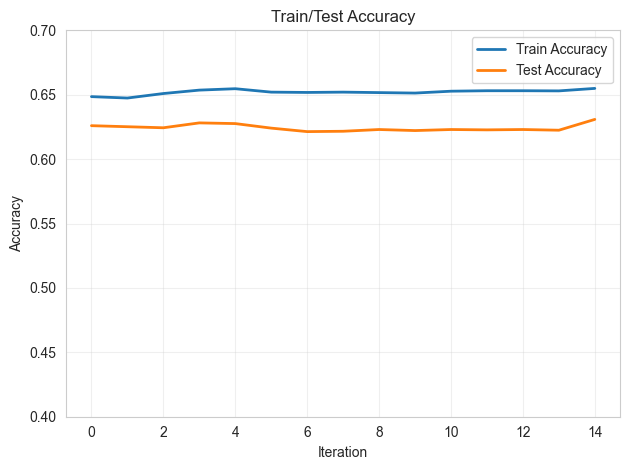

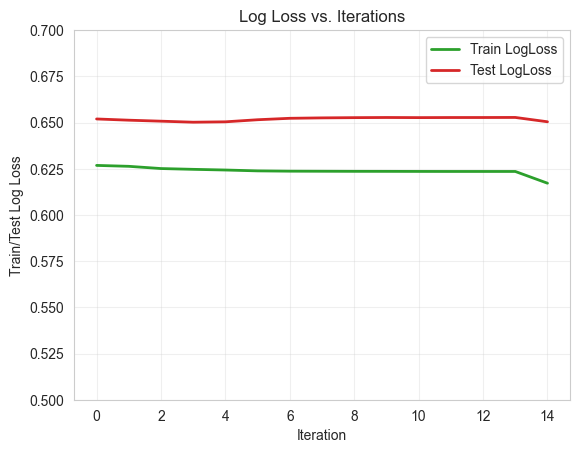

In [52]:
# --- Convert to numpy arrays for plotting ---
hist_grid = result["history"]

# convert arrays safely
iters     = np.array(hist_grid["iter"], dtype=float)
train_acc = np.array(hist_grid["train_acc"], dtype=float)
test_acc  = np.array(hist_grid["test_acc"], dtype=float)
train_ll  = np.array(hist_grid["train_logloss"], dtype=float)
test_ll   = np.array(hist_grid["test_logloss"], dtype=float)

# --- 1Train vs Test Accuracy ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Train vs Test Log-Loss ---
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.5, 0.7)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Method 2: Bayesian Search

In [56]:
space  = [
    Real(1e-9, 1e1,   "log-uniform", name="lambda_s"),
    Real(1e-9, 1e1,   "log-uniform", name="lambda_b"),
    Real(1e-9, 1e1, "log-uniform", name="lambda_g"),
]

all_results = []

@use_named_args(space)
def objective(lambda_s, lambda_b,lambda_g):
    print(f"Trying λs={lambda_s:.4e}, λb={lambda_b:.4e}, λg={lambda_g:.4e}")


    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=lambda_s,
        lambda_b=lambda_b,
        lambda_g=lambda_g,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )

    result = model.fit(
        df=df,
        split_col="split",
        split_value="train",
        test_frame=test,
        max_iter=800,
        verbose=1,
    )

    acc, logloss = model.evaluate(test)

    print(f"Accuracy: {acc:.6f}")
    print(f"Logloss: {logloss:.6f}")

    # record each step for analysis later
    all_results.append({
        "lambda_s": lambda_s,
        "lambda_b": lambda_b,
        "lambda_g": lambda_g,
        "accuracy": acc,
        "logloss": logloss,
    })

    return -acc

In [57]:
result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=50,           # number of trials (start with 25–50)
    n_initial_points=10,  # random explorations before GP fit
    random_state=42,
    acq_func="EI"         # Expected Improvement
)

Trying λs=9.2349e-02, λb=6.8289e-08, λg=6.2648e-02
Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6229 ll=0.6498
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6333 ll=0.6482
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6335 ll=0.6483
[0003] Train acc=0.6571 ll=0.6192 | Test acc=0.6376 ll=0.6475
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6368 ll=0.6475
[0005] Train acc=0.6561 ll=0.6182 | Test acc=0.6335 ll=0.6485
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6348 ll=0.6488
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6333 ll=0.6494
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6323 ll=0.6496
[0009] Train acc=0.6573 ll=0.6178 | Test acc=0.6315 ll=0.6499
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6325 ll=0.6500
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6320 ll=0.6501
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6315 ll=0.6500
[0013] Train acc=0.6561 ll=0.6178 | Test acc=0.6315 ll=0.6501
[0014] Train acc=0.6560 ll=0.6178 | Test acc=0.6328 ll=0.6501
[0015] Train acc=0.6564 ll=0.6178 | Test acc=0.6315 ll=0.6502
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6229 ll=0.6498
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6333 ll=0.6482
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6335 ll=0.6483
[0003] Train acc=0.6571 ll=0.6192 | Test acc=0.6376 ll=0.6475
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6368 ll=0.6475
[0005] Train acc=0.6561 ll=0.6182 | Test acc=0.6335 ll=0.6485
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6348 ll=0.6488
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6333 ll=0.6494
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6323 ll=0.6496
[0009] Train acc=0.6573 ll=0.6178 | Test acc=0.6315 ll=0.6499
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6325 ll=0.6500
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6320 ll=0.6501
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6315 ll=0.6500
[0013] Train acc=0.6561 ll=0.6178 | Test acc=0.6315 ll=0.6501
[0014] Train acc=0.6560 ll=0.6178 | Test acc=0.6328 ll=0.6501
[0015] Train acc=0.6564 ll=0.6178 | Test acc=0.6315 ll=0.6502
[0016] T

...

[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6227 ll=0.6498
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6333 ll=0.6482
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6333 ll=0.6483
[0003] Train acc=0.6570 ll=0.6192 | Test acc=0.6376 ll=0.6475
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6368 ll=0.6475
[0005] Train acc=0.6560 ll=0.6182 | Test acc=0.6335 ll=0.6486
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6348 ll=0.6488
[0007] Train acc=0.6556 ll=0.6179 | Test acc=0.6333 ll=0.6493
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6323 ll=0.6496
[0009] Train acc=0.6575 ll=0.6178 | Test acc=0.6315 ll=0.6499
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6325 ll=0.6500
[0011] Train acc=0.6558 ll=0.6178 | Test acc=0.6320 ll=0.6500
[0012] Train acc=0.6562 ll=0.6178 | Test acc=0.6320 ll=0.6500
[0013] Train acc=0.6562 ll=0.6178 | Test acc=0.6323 ll=0.6500
[0014] Train acc=0.6561 ll=0.6178 | Test acc=0.6318 ll=0.6500
[0015] Train acc=0.6561 ll=0.6178 | Test acc=0.6318 ll=0.6500
Estimate

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6229 ll=0.6498
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6333 ll=0.6482
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6335 ll=0.6483
[0003] Train acc=0.6571 ll=0.6192 | Test acc=0.6376 ll=0.6475
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6368 ll=0.6475
[0005] Train acc=0.6561 ll=0.6182 | Test acc=0.6335 ll=0.6485
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6348 ll=0.6488
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6333 ll=0.6494
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6323 ll=0.6496
[0009] Train acc=0.6573 ll=0.6178 | Test acc=0.6315 ll=0.6499
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6325 ll=0.6500
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6320 ll=0.6501
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6315 ll=0.6500
[0013] Train acc=0.6561 ll=0.6178 | Test acc=0.6315 ll=0.6501
[0014] Train acc=0.6560 ll=0.6178 | Test acc=0.6328 ll=0.6501
[0015] Train acc=0.6564 ll=0.6178 | Test acc=0.6315 ll=0.6502
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6229 ll=0.6498
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6333 ll=0.6482
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6335 ll=0.6483
[0003] Train acc=0.6571 ll=0.6192 | Test acc=0.6376 ll=0.6475
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6368 ll=0.6475
[0005] Train acc=0.6561 ll=0.6182 | Test acc=0.6335 ll=0.6485
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6348 ll=0.6488
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6333 ll=0.6494
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6323 ll=0.6496
[0009] Train acc=0.6573 ll=0.6178 | Test acc=0.6315 ll=0.6499
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6325 ll=0.6500
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6320 ll=0.6501
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6315 ll=0.6500
[0013] Train acc=0.6561 ll=0.6178 | Test acc=0.6315 ll=0.6501
[0014] Train acc=0.6560 ll=0.6178 | Test acc=0.6328 ll=0.6501
[0015] Train acc=0.6564 ll=0.6178 | Test acc=0.6315 ll=0.6502
[0016] T


Optimization completed
Best parameters: λs=3.5574e+00, λb=4.2208e-02, λg=1.9023e-01
Best accuracy: 0.632256
Best logloss: 0.650115


<Axes: >

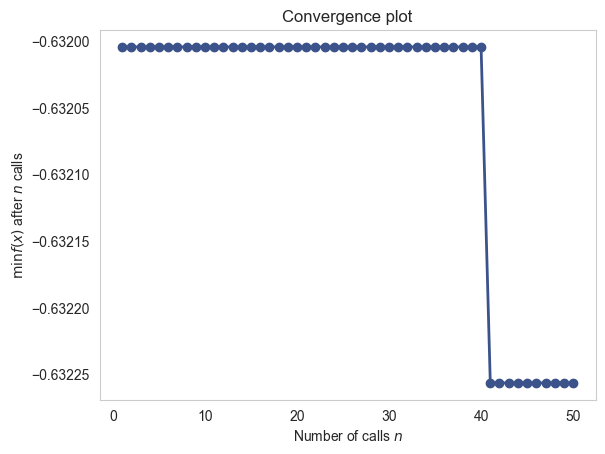

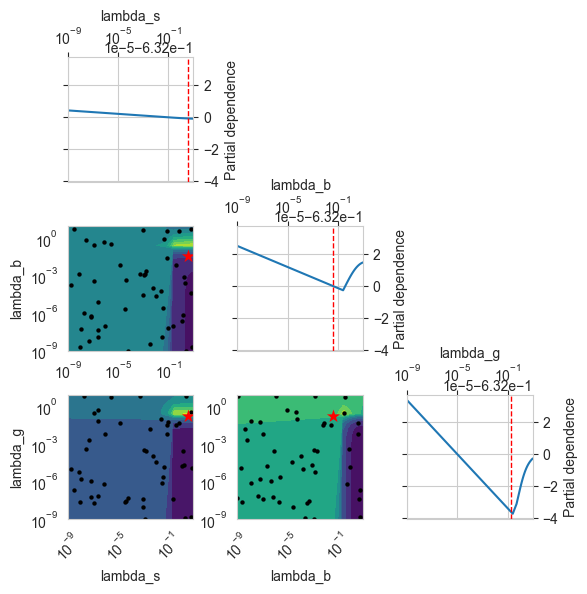

In [58]:
# best parameters found
best_lambda_s, best_lambda_b, best_lambda_g = result.x
# convert back to positive accuracy
best_acc = -result.fun
# find the matching logloss from our stored results
best_entry = min(all_results, key=lambda r: abs(r["accuracy"] - best_acc))
best_logloss = best_entry["logloss"]

print("\nOptimization completed")
print(f"Best parameters: λs={best_lambda_s:.4e}, λb={best_lambda_b:.4e}, λg={best_lambda_g:.4e}")
print(f"Best accuracy: {best_acc:.6f}")
print(f"Best logloss: {best_logloss:.6f}")

plot_convergence(result)
plot_objective(result)

In [59]:
model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=3.5574e+00,
    lambda_b=4.2208e-02,
    lambda_g=1.9023e-01,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context, sd_context=sd_context
)


result = model.fit(
    df,
    split_col="split",
    split_value="train",
    max_iter=10000,
    verbose=1,
    test_frame=test,
)

# Final metrics (you can also recompute)
tr_acc,tr_ll = model.evaluate(train)
t_acc, t_ll = model.evaluate(test)
print(f"Train Metric -> acc={tr_acc:.6f} ll={tr_ll:.6f}")
print(f"Test Metric -> acc={t_acc:.6f} ll={t_ll:.6f}")

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6227 ll=0.6498
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6333 ll=0.6482
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6335 ll=0.6483
[0003] Train acc=0.6570 ll=0.6192 | Test acc=0.6376 ll=0.6475
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6368 ll=0.6475
[0005] Train acc=0.6560 ll=0.6182 | Test acc=0.6335 ll=0.6485
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6348 ll=0.6488
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6333 ll=0.6493
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6323 ll=0.6496
[0009] Train acc=0.6574 ll=0.6178 | Test acc=0.6315 ll=0.6499
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6325 ll=0.6500
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6320 ll=0.6501
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6315 ll=0.6500
[0013] Train acc=0.6562 ll=0.6178 | Test acc=0.6315 ll=0.6501
[0014] Train acc=0.6563 ll=0.6178 | Test acc=0.6320 ll=0.6501
[0015] Tra

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


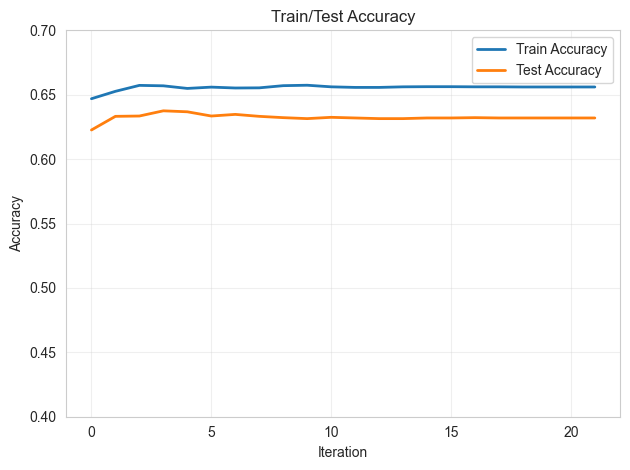

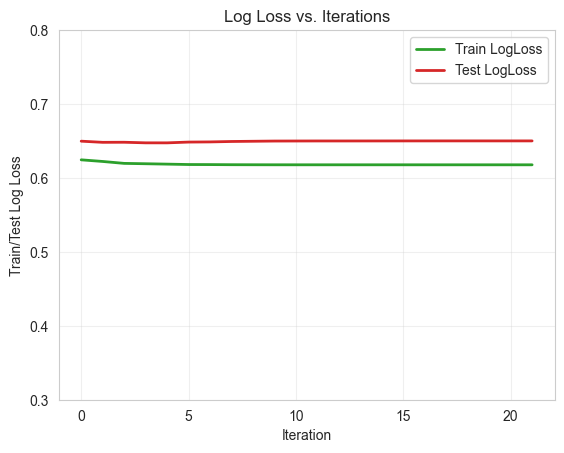

In [60]:
# --- Convert to numpy arrays for plotting ---
hist_baye = result["history"]

# convert arrays safely
iters     = np.array(hist_baye["iter"], dtype=float)
train_acc = np.array(hist_baye["train_acc"], dtype=float)
test_acc  = np.array(hist_baye["test_acc"], dtype=float)
train_ll  = np.array(hist_baye["train_logloss"], dtype=float)
test_ll   = np.array(hist_baye["test_logloss"], dtype=float)

# --- 1Train vs Test Accuracy ---
plt.plot(iters, train_acc, label="Train Accuracy", color="#1f77b4", lw=2)
plt.plot(iters, test_acc,  label="Test Accuracy",  color="#ff7f0e", lw=2)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.ylim(0.4, 0.7)
plt.title("Train/Test Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Train vs Test Log-Loss ---
plt.plot(iters, train_ll, label="Train LogLoss", color="#2ca02c", lw=2)
plt.plot(iters, test_ll,  label="Test LogLoss",  color="#d62728", lw=2)
ymin = np.nanmin([train_ll.min(), test_ll.min()])
ymax = np.nanmax([train_ll.max(), test_ll.max()])
plt.ylim(0.3, 0.8)
plt.xlabel("Iteration"); plt.ylabel("Train/Test Log Loss")
plt.title("Log Loss vs. Iterations"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Stratified KFold

Select Best K

In [69]:
all_results = []  # store every (k, fold) combination

for K in [3, 5, 8, 10, 15, 20, 30]:
    print(f"\nRunning Stratified {K}-Fold CV...")
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(df, df["home_win"]), 1):
        train, test = df.iloc[train_idx], df.iloc[test_idx]

        model = BTWithCovariates(
            teams=teams,
            team_to_idx=team_to_idx,
            s=s_init,
            beta=beta_init,
            feature_cols=feature_cols,
            mu=mu,
            sd=sd,
            context_cols=context_cols,
            gamma=gamma_init,
            mu_context=mu_context,
            sd_context=sd_context,
            lambda_s=3.5574,
            lambda_b=4.2208e-02,
            lambda_g=1.9023e-01
        )

        model.fit(train, max_iter=1200, verbose=1)
        train_acc, train_ll = model.evaluate(train)
        test_acc, test_ll = model.evaluate(test)

        fold_results.append({
            "k": K,
            "fold": fold,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "train_ll": train_ll,
            "test_ll": test_ll,
        })

    all_results.extend(fold_results)

results_df = pd.DataFrame(all_results)


Running Stratified 3-Fold CV...
Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6502 ll=0.6269 | Test acc=nan ll=nan
[0001] Train acc=0.6537 ll=0.6250 | Test acc=nan ll=nan
[0002] Train acc=0.6583 ll=0.6227 | Test acc=nan ll=nan
[0003] Train acc=0.6588 ll=0.6223 | Test acc=nan ll=nan
[0004] Train acc=0.6609 ll=0.6217 | Test acc=nan ll=nan
[0005] Train acc=0.6592 ll=0.6214 | Test acc=nan ll=nan
[0006] Train acc=0.6612 ll=0.6214 | Test acc=nan ll=nan
[0007] Train acc=0.6588 ll=0.6212 | Test acc=nan ll=nan
[0008] Train acc=0.6590 ll=0.6212 | Test acc=nan ll=nan
[0009] Train acc=0.6594 ll=0.6212 | Test acc=nan ll=nan
[0010] Train acc=0.6592 ll=0.6212 | Test acc=nan ll=nan
[0011] Train acc=0.6592 ll=0.6212 | Test acc=nan ll=nan
[0012] Train acc=0.6590 ll=0.6212 | Test acc=nan ll=nan
[0013] Train acc=0.6590 ll=0.6212 | Test acc=nan ll=nan
[0014] Train acc=0.6589 ll=0.6212 | Test acc=nan ll=nan
[0015] Train acc=0.6589 ll=0.6212 | Test acc=nan ll=nan
[0016] Train acc=0.6589 ll=0.6212 | Test acc=nan ll=nan
Estimated global home‑court multiplier θ̄ = 1.37

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6454 ll=0.6331 | Test acc=nan ll=nan
[0001] Train acc=0.6491 ll=0.6313 | Test acc=nan ll=nan
[0002] Train acc=0.6518 ll=0.6286 | Test acc=nan ll=nan
[0003] Train acc=0.6503 ll=0.6280 | Test acc=nan ll=nan
[0004] Train acc=0.6522 ll=0.6274 | Test acc=nan ll=nan
[0005] Train acc=0.6533 ll=0.6271 | Test acc=nan ll=nan
[0006] Train acc=0.6508 ll=0.6270 | Test acc=nan ll=nan
[0007] Train acc=0.6523 ll=0.6268 | Test acc=nan ll=nan
[0008] Train acc=0.6534 ll=0.6268 | Test acc=nan ll=nan
[0009] Train acc=0.6534 ll=0.6267 | Test acc=nan ll=nan
[0010] Train acc=0.6534 ll=0.6267 | Test acc=nan ll=nan
[0011] Train acc=0.6533 ll=0.6267 | Test acc=nan ll=nan
[0012] Train acc=0.6532 ll=0.6267 | Test acc=nan ll=nan
[0013] Train acc=0.6532 ll=0.6267 | Test acc=nan ll=nan
[0014] Train acc=0.6530 ll=0.6267 | Test acc=nan ll=nan
[0015] Train acc=0.6535 ll=0.6267 | Test acc=nan ll=nan
[0016] Train acc=0.6532 ll=0.6267 | Test acc=nan ll=nan
[0017] Train acc=0.6532 ll=0.6267 | Test acc=nan

...

[0000] Train acc=0.6470 ll=0.6309 | Test acc=nan ll=nan
[0001] Train acc=0.6509 ll=0.6291 | Test acc=nan ll=nan
[0002] Train acc=0.6537 ll=0.6266 | Test acc=nan ll=nan
[0003] Train acc=0.6540 ll=0.6260 | Test acc=nan ll=nan
[0004] Train acc=0.6533 ll=0.6254 | Test acc=nan ll=nan
[0005] Train acc=0.6540 ll=0.6252 | Test acc=nan ll=nan
[0006] Train acc=0.6545 ll=0.6252 | Test acc=nan ll=nan
[0007] Train acc=0.6554 ll=0.6250 | Test acc=nan ll=nan
[0008] Train acc=0.6561 ll=0.6250 | Test acc=nan ll=nan
[0009] Train acc=0.6561 ll=0.6250 | Test acc=nan ll=nan
[0010] Train acc=0.6558 ll=0.6250 | Test acc=nan ll=nan
[0011] Train acc=0.6553 ll=0.6250 | Test acc=nan ll=nan
[0012] Train acc=0.6553 ll=0.6250 | Test acc=nan ll=nan
[0013] Train acc=0.6554 ll=0.6250 | Test acc=nan ll=nan
[0014] Train acc=0.6559 ll=0.6250 | Test acc=nan ll=nan
[0015] Train acc=0.6554 ll=0.6250 | Test acc=nan ll=nan
[0016] Train acc=0.6554 ll=0.6250 | Test acc=nan ll=nan
[0017] Train acc=0.6554 ll=0.6250 | Test acc=nan

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6450 ll=0.6311 | Test acc=nan ll=nan
[0001] Train acc=0.6489 ll=0.6292 | Test acc=nan ll=nan
[0002] Train acc=0.6526 ll=0.6267 | Test acc=nan ll=nan
[0003] Train acc=0.6539 ll=0.6262 | Test acc=nan ll=nan
[0004] Train acc=0.6540 ll=0.6256 | Test acc=nan ll=nan
[0005] Train acc=0.6542 ll=0.6253 | Test acc=nan ll=nan
[0006] Train acc=0.6552 ll=0.6253 | Test acc=nan ll=nan
[0007] Train acc=0.6546 ll=0.6251 | Test acc=nan ll=nan
[0008] Train acc=0.6546 ll=0.6251 | Test acc=nan ll=nan
[0009] Train acc=0.6542 ll=0.6251 | Test acc=nan ll=nan
[0010] Train acc=0.6541 ll=0.6251 | Test acc=nan ll=nan
[0011] Train acc=0.6540 ll=0.6251 | Test acc=nan ll=nan
[0012] Train acc=0.6543 ll=0.6251 | Test acc=nan ll=nan
[0013] Train acc=0.6542 ll=0.6251 | Test acc=nan ll=nan
[0014] Train acc=0.6545 ll=0.6251 | Test acc=nan ll=nan
[0015] Train acc=0.6545 ll=0.6251 | Test acc=nan ll=nan
[0016] Train acc=0.6545 ll=0.6251 | Test acc=nan ll=nan
Estimated global home‑court multiplier θ̄ = 1.37

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6466 ll=0.6305 | Test acc=nan ll=nan
[0001] Train acc=0.6496 ll=0.6286 | Test acc=nan ll=nan
[0002] Train acc=0.6531 ll=0.6262 | Test acc=nan ll=nan
[0003] Train acc=0.6538 ll=0.6256 | Test acc=nan ll=nan
[0004] Train acc=0.6540 ll=0.6251 | Test acc=nan ll=nan
[0005] Train acc=0.6531 ll=0.6248 | Test acc=nan ll=nan
[0006] Train acc=0.6537 ll=0.6248 | Test acc=nan ll=nan
[0007] Train acc=0.6544 ll=0.6246 | Test acc=nan ll=nan
[0008] Train acc=0.6547 ll=0.6246 | Test acc=nan ll=nan
[0009] Train acc=0.6535 ll=0.6246 | Test acc=nan ll=nan
[0010] Train acc=0.6537 ll=0.6246 | Test acc=nan ll=nan
[0011] Train acc=0.6538 ll=0.6246 | Test acc=nan ll=nan
[0012] Train acc=0.6538 ll=0.6246 | Test acc=nan ll=nan
[0013] Train acc=0.6537 ll=0.6246 | Test acc=nan ll=nan
[0014] Train acc=0.6537 ll=0.6246 | Test acc=nan ll=nan
[0015] Train acc=0.6536 ll=0.6246 | Test acc=nan ll=nan
[0016] Train acc=0.6536 ll=0.6246 | Test acc=nan ll=nan
[0017] Train acc=0.6536 ll=0.6246 | Test acc=nan

In [70]:
summary_df = results_df.groupby("k").agg(
    mean_train_acc=("train_acc", "mean"),
    std_train_acc=("train_acc", "std"),
    mean_test_acc=("test_acc", "mean"),
    std_test_acc=("test_acc", "std"),
).reset_index()

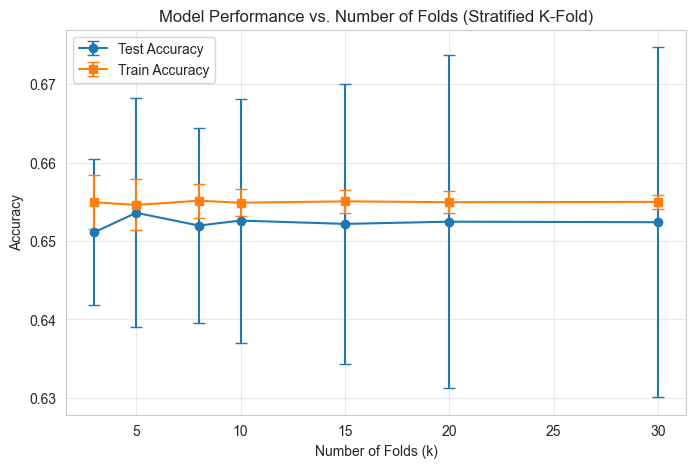

In [71]:
plt.figure(figsize=(8,5))

# Accuracy plot
plt.errorbar(summary_df["k"], summary_df["mean_test_acc"],
             yerr=summary_df["std_test_acc"], fmt='-o', capsize=4, label="Test Accuracy")
plt.errorbar(summary_df["k"], summary_df["mean_train_acc"],
             yerr=summary_df["std_train_acc"], fmt='-s', capsize=4, label="Train Accuracy")

plt.title("Model Performance vs. Number of Folds (Stratified K-Fold)")
plt.xlabel("Number of Folds (k)")
plt.ylabel("Accuracy")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

K=10 since it decays after this node

In [72]:
K = 10    #chosen from empirical test
max_iter = 1200

fold_results = []
df_cv = df[df["split"].isin(["train", "test"])]
y = df_cv["home_win"].values

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)


for fold, (train_idx, test_idx) in enumerate(skf.split(df_cv, y), 1):
    print(f"\nFold {fold}/{K}")

    train_df = df_cv.iloc[train_idx].copy()
    test_df  = df_cv.iloc[test_idx].copy()

    model = BTWithCovariates(
        teams=teams,
        team_to_idx=team_to_idx,
        s=s_init,
        beta=beta_init,
        feature_cols=feature_cols,
        mu=mu,
        sd=sd,
        lambda_s=3.5574e+00,
        lambda_b=4.2208e-02,
        lambda_g=1.9023e-01,
        threshold=0.5,
        context_cols=context_cols,
        gamma=gamma_init,
        mu_context=mu_context, sd_context=sd_context
    )


    result = model.fit(
        df_cv,
        split_col="split",
        split_value="train",
        max_iter=10000,
        verbose=1,
        test_frame=test,
    )

    train_acc, train_ll = model.evaluate(train_df)
    test_acc, test_ll   = model.evaluate(test_df)

    fold_results.append({
        "fold": fold,
        "train_acc": train_acc,
        "train_ll": train_ll,
        "test_acc": test_acc,
        "test_ll": test_ll,
    })

    print(
        f"Fold {fold:>2}: Train acc={train_acc:.4f}, logloss={train_ll:.4f} | "
        f"Test acc={test_acc:.4f}, logloss={test_ll:.4f}"
    )

# ---- Summaries ----
results_df = pd.DataFrame(fold_results)
print("\nCross‑Validation Summary (K=12)")
print(results_df)
print("\nMean metrics across folds:")
print(results_df.mean(numeric_only=True).to_frame().T.round(4))


Fold 1/10
Running 5 MM iterations for initial team strength update...


C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6518 ll=0.6440
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6582 ll=0.6415
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6603 ll=0.6401
[0003] Train acc=0.6570 ll=0.6192 | Test acc=0.6603 ll=0.6392
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6561 ll=0.6395
[0005] Train acc=0.6560 ll=0.6182 | Test acc=0.6561 ll=0.6397
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6561 ll=0.6408
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6539 ll=0.6405
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6539 ll=0.6404
[0009] Train acc=0.6574 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6582 ll=0.6407
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6582 ll=0.6407
[0013] Train acc=0.6562 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0014] Train acc=0.6563 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0015] Train acc=0.6563 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6518 ll=0.6440
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6582 ll=0.6415
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6603 ll=0.6401
[0003] Train acc=0.6570 ll=0.6192 | Test acc=0.6603 ll=0.6392
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6561 ll=0.6395
[0005] Train acc=0.6560 ll=0.6182 | Test acc=0.6561 ll=0.6397
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6561 ll=0.6408
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6539 ll=0.6405
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6539 ll=0.6404
[0009] Train acc=0.6574 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6582 ll=0.6407
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6582 ll=0.6407
[0013] Train acc=0.6562 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0014] Train acc=0.6563 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0015] Train acc=0.6563 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0016] T

...

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6518 ll=0.6440
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6582 ll=0.6415
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6603 ll=0.6401
[0003] Train acc=0.6570 ll=0.6192 | Test acc=0.6603 ll=0.6392
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6561 ll=0.6395
[0005] Train acc=0.6560 ll=0.6182 | Test acc=0.6561 ll=0.6397
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6561 ll=0.6408
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6539 ll=0.6405
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6539 ll=0.6404
[0009] Train acc=0.6574 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6582 ll=0.6407
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6582 ll=0.6407
[0013] Train acc=0.6562 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0014] Train acc=0.6563 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0015] Train acc=0.6563 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


[0000] Train acc=0.6469 ll=0.6245 | Test acc=0.6518 ll=0.6440
[0001] Train acc=0.6527 ll=0.6223 | Test acc=0.6582 ll=0.6415
[0002] Train acc=0.6573 ll=0.6197 | Test acc=0.6603 ll=0.6401
[0003] Train acc=0.6570 ll=0.6192 | Test acc=0.6603 ll=0.6392
[0004] Train acc=0.6549 ll=0.6187 | Test acc=0.6561 ll=0.6395
[0005] Train acc=0.6560 ll=0.6182 | Test acc=0.6561 ll=0.6397
[0006] Train acc=0.6553 ll=0.6181 | Test acc=0.6561 ll=0.6408
[0007] Train acc=0.6554 ll=0.6179 | Test acc=0.6539 ll=0.6405
[0008] Train acc=0.6571 ll=0.6179 | Test acc=0.6539 ll=0.6404
[0009] Train acc=0.6574 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0010] Train acc=0.6562 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0011] Train acc=0.6557 ll=0.6178 | Test acc=0.6582 ll=0.6407
[0012] Train acc=0.6557 ll=0.6178 | Test acc=0.6582 ll=0.6407
[0013] Train acc=0.6562 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0014] Train acc=0.6563 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0015] Train acc=0.6563 ll=0.6178 | Test acc=0.6582 ll=0.6406
[0016] T

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\3705724520.py:25: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


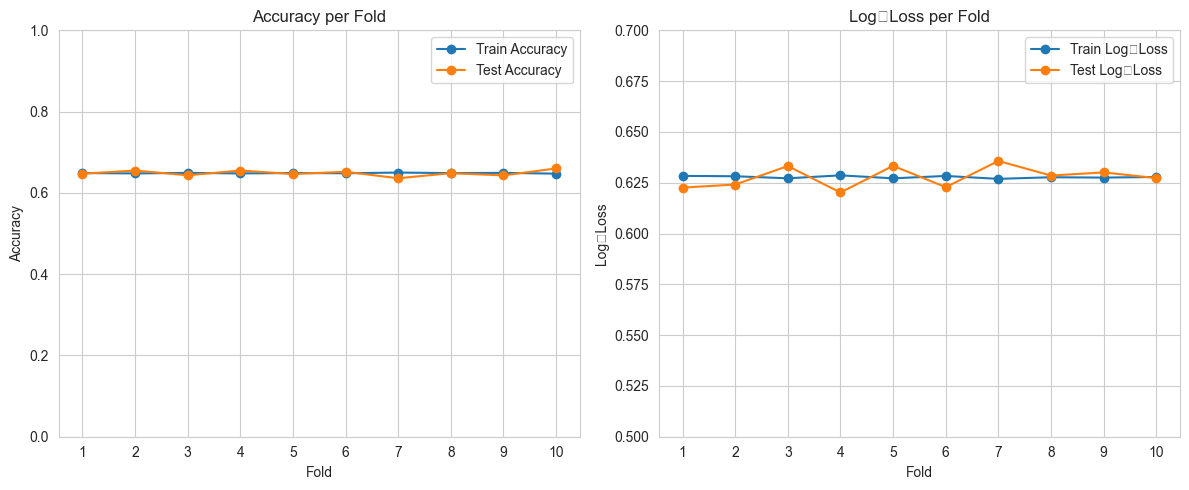


Cross‑validated accuracy (95% CI): 0.649 [0.644, 0.653]


In [73]:
# Figure setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----- Plot 1: Accuracy -----
axes[0].plot(results_df["fold"], results_df["train_acc"], marker="o", label="Train Accuracy")
axes[0].plot(results_df["fold"], results_df["test_acc"], marker="o", label="Test Accuracy")
axes[0].set_title("Accuracy per Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[1].set_ylim(0.5,0.7)
axes[0].set_xticks(results_df["fold"])
axes[0].legend()
axes[0].set_ylim(0, 1)  # accuracy ranges 0-1

# ----- Plot 2: Log‑Loss -----
axes[1].plot(results_df["fold"], results_df["train_ll"], marker="o", label="Train Log‑Loss")
axes[1].plot(results_df["fold"], results_df["test_ll"], marker="o", label="Test Log‑Loss")
axes[1].set_ylim(0.5,0.7)
axes[1].set_title("Log‑Loss per Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Log‑Loss")
axes[1].set_xticks(results_df["fold"])
axes[1].legend()

plt.tight_layout()
plt.show()

mean_acc = results_df["test_acc"].mean()
std_acc = results_df["test_acc"].std()
conf_low = mean_acc - 1.96 * std_acc / (K ** 0.5)
conf_high = mean_acc + 1.96 * std_acc / (K ** 0.5)

print(f"\nCross‑validated accuracy (95% CI): {mean_acc:.3f} "
      f"[{conf_low:.3f}, {conf_high:.3f}]")

### Finalized Model

In [74]:
final_df = df[df["split"] == "valid"]
final_df.drop(["split"], axis=1, inplace=True)
final_df.head()

C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\4279595533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.drop(["split"], axis=1, inplace=True)


,season,GAME_ID,home_abbr,away_abbr,home_win,home_b2b,away_b2b,home_rest_days,away_rest_days,rest_diff,diff_recent_margin,diff_recent_win_pct,diff_pts_pg_to_date,split_win_pct_delta,season_start_year,Game_Type
12836,2024-25,42400407,OKC,IND,1,0.0,0,2.0,2.0,0.0,1.6,0.1,9.266330,0.312013,2024,playoff
12837,2024-25,42400406,IND,OKC,1,0.0,0,2.0,2.0,0.0,-7.1,-0.2,-9.665781,-0.043179,2024,playoff
12838,2024-25,42400405,OKC,IND,1,0.0,0,2.0,2.0,0.0,7.8,0.1,9.549266,0.299327,2024,playoff
12839,2024-25,42400404,IND,OKC,0,0.0,0,1.0,1.0,0.0,-4.3,0.1,-9.506008,-0.024510,2024,playoff
12840,2024-25,42400403,IND,OKC,1,0.0,0,2.0,2.0,0.0,-4.8,0.0,-9.766691,-0.044706,2024,playoff


In [78]:
final_model = BTWithCovariates(
    teams=teams,
    team_to_idx=team_to_idx,
    s=s_init,
    beta=beta_init,
    feature_cols=feature_cols,
    mu=mu,
    sd=sd,
    lambda_s=3.5574e+00,
    lambda_b=4.2208e-02,
    lambda_g=1.9023e-01,
    threshold=0.5,
    context_cols=context_cols,
    gamma=gamma_init,
    mu_context=mu_context,
    sd_context=sd_context,
)

# Fit using all combined training data
final_model.fit(
    df=final_df,
    max_iter=max_iter,
    verbose=1,
)

Running 5 MM iterations for initial team strength update...
[0000] Train acc=0.6715 ll=0.6005 | Test acc=nan ll=nan
[0001] Train acc=0.6768 ll=0.5983 | Test acc=nan ll=nan
[0002] Train acc=0.6768 ll=0.5927 | Test acc=nan ll=nan
[0003] Train acc=0.6783 ll=0.5901 | Test acc=nan ll=nan
[0004] Train acc=0.6843 ll=0.5861 | Test acc=nan ll=nan
[0005] Train acc=0.6836 ll=0.5829 | Test acc=nan ll=nan
[0006] Train acc=0.6874 ll=0.5817 | Test acc=nan ll=nan
[0007] Train acc=0.7033 ll=0.5785 | Test acc=nan ll=nan
[0008] Train acc=0.7055 ll=0.5782 | Test acc=nan ll=nan
[0009] Train acc=0.7025 ll=0.5782 | Test acc=nan ll=nan
[0010] Train acc=0.7010 ll=0.5781 | Test acc=nan ll=nan
[0011] Train acc=0.6995 ll=0.5781 | Test acc=nan ll=nan
Estimated global home‑court multiplier θ̄ = 1.2854
Final: Train acc=0.6995, logloss=0.5781


C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\363860280.py:231: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


{'opt_result':   message: ABNORMAL: 
   success: False
    status: 2
       fun: 777.3716792461753
         x: [ 6.609e-02 -6.494e-01 ...  4.642e-02  2.511e-01]
       nit: 12
       jac: [ 3.569e-01  1.651e+00 ...  1.815e-01 -8.613e-01]
      nfev: 112
      njev: 112
  hess_inv: <40x40 LbfgsInvHessProduct with dtype=float64>,
 'history': {'iter': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
  'train_acc': [np.float64(0.6714610143830432),
   np.float64(0.6767600302800908),
   np.float64(0.6767600302800908),
   np.float64(0.6782740348221045),
   np.float64(0.6843300529901589),
   np.float64(0.6835730507191522),
   np.float64(0.6873580620741863),
   np.float64(0.7032551097653293),
   np.float64(0.7055261165783497),
   np.float64(0.7024981074943225),
   np.float64(0.7009841029523088),
   np.float64(0.6994700984102953),
   np.float64(0.6994700984102953)],
  'train_logloss': [np.float64(0.6005321431272371),
   np.float64(0.5982907422072923),
   np.float64(0.5926556569741903),
   np.float64(

### Save Model

In [79]:
save_model(
    final_model,
    path_npz="models/btwithcovariates_fold10_new1.npz",
    path_json="models/btwithcovariates_fold10_new1.json",
    extra_meta={"K": K, "max_iter": max_iter},
)

Model parameters saved to models/btwithcovariates_fold10_new1.json
Model saved successfully to models/btwithcovariates_fold10_new1.npz


### 1.B Validation

Model loaded successfully from models/btwithcovariates_fold10_new1.npz
Teams: 30 | Features: 4


C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\1162813561.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df["HCA_context"] = Z_valid @ model.gamma
C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\1162813561.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df["HCA_total"] = model.alpha_hca + Z_valid @ model.gamma
C:\Users\hosiu\AppData\Local\Temp\ipykernel_44396\1162813561.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

,home_abbr,away_abbr,HCA_total,theta_game,pred_prob_home_win,pred_label,home_win
12836,OKC,IND,0.002153,1.002155,0.610425,1,1
12837,IND,OKC,0.002153,1.002155,0.359151,0,1
12838,OKC,IND,0.002153,1.002155,0.675995,1,1
12839,IND,OKC,0.109453,1.115668,0.333494,0,0
12840,IND,OKC,0.002153,1.002155,0.329995,0,1
...,...,...,...,...,...,...,...
14152,SAS,IND,-0.231148,0.793622,0.212995,0,1
14153,IND,SAS,0.109453,1.115668,0.724413,1,1
14154,MIL,ATL,0.020855,1.021074,0.616535,1,1
14155,OKC,HOU,0.020855,1.021074,0.724562,1,1


Evaluation Metrics on Validation Data
Accuracy : 0.7033
Log Loss : 0.5805
Precision: 0.7368
Recall   : 0.7123
F1 Score : 0.7243


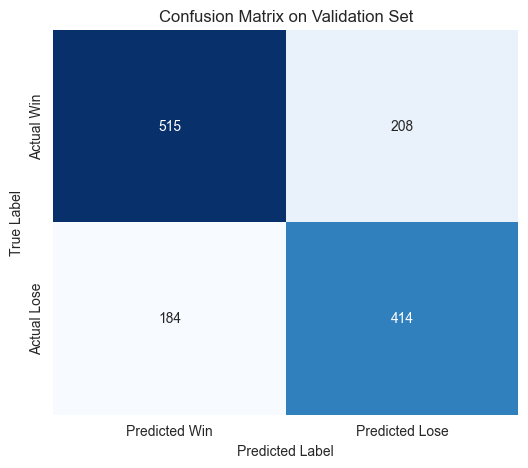

In [87]:
model = load_model("models/btwithcovariates_fold10_new1.npz")
val_df = df[df["split"] == "valid"]
valid_df = df[df["split"] == "valid"]

# Standardize context columns
Z_valid = np.zeros((len(valid_df), len(model.context_cols)))
for j, col in enumerate(model.context_cols):
    Z_valid[:, j] = (valid_df[col] - model.mu_context[j]) / model.sd_context[j]
# Compute contextual home advantage for each game
valid_df["HCA_context"] = Z_valid @ model.gamma
valid_df["HCA_total"] = model.alpha_hca + Z_valid @ model.gamma
valid_df["theta_game"] = np.exp(valid_df["HCA_total"])

valid_df["pred_prob_home_win"] = model.predict_proba(valid_df)
# For classification label
valid_df["pred_label"] = (valid_df["pred_prob_home_win"] >= model.threshold).astype(int)
valid_df = valid_df[(valid_df["home_abbr"] != "NONE") & (valid_df["away_abbr"].notna())]
valid_df=valid_df[["home_abbr", "away_abbr", "HCA_total", "theta_game", "pred_prob_home_win", "pred_label","home_win"]]
display(valid_df)

valid_df.to_csv("./results/valid_result.csv", index=False)

# --- Extract prediction and true labels ---
y_true = valid_df["home_win"]
y_pred = valid_df["pred_label"]

# --- Compute evaluation metrics ---
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
logloss = log_loss(y_true, valid_df["pred_prob_home_win"])

# --- Print summary ---
print("Evaluation Metrics on Validation Data")
print(f"Accuracy : {acc:.4f}")
print(f"Log Loss : {logloss:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
cm_display = ConfusionMatrixDisplay(cm, display_labels=["Home Win (1)", "Home Lose (0)"])

# --- Visualize nicely ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Win", "Predicted Lose"],
            yticklabels=["Actual Win", "Actual Lose"])
plt.title("Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

count    1321.000000
mean        1.087643
std         0.250691
min         0.410478
25%         0.984026
50%         1.115668
75%         1.115668
max         1.741217
Name: theta_game, dtype: float64


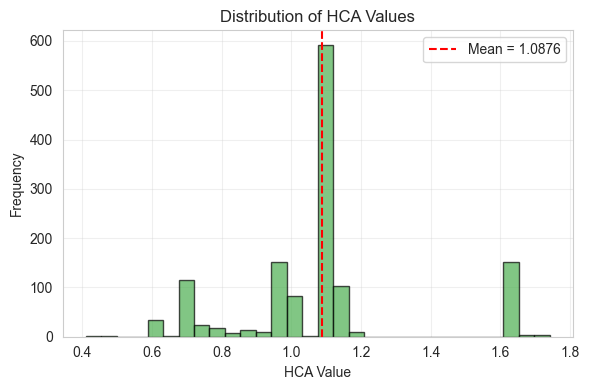

In [81]:
print(valid_df["theta_game"].describe())
HCA= valid_df["theta_game"]
plt.figure(figsize=(6, 4))
plt.hist(HCA, bins=30, color="#4CAF50", alpha=0.7, edgecolor="black")
plt.axvline(HCA.mean(), color="red", linestyle="--", label=f"Mean = {HCA.mean():.4f}")
plt.title("Distribution of HCA Values")
plt.xlabel("HCA Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
pair_summary = (
    valid_df
    .groupby(["home_abbr", "away_abbr"], as_index=False)
    .agg(
        avg_HCA=("HCA_total", "mean"),
        avg_pred_prob_home_win=("pred_prob_home_win", "mean"),
        total_home_win=("home_win", "sum"),
        total_predicted_win=("pred_label", "sum"),
        total_games=("pred_label", "count")
    )
)

# Complementary counts
pair_summary["total_predicted_lose"] = (
    pair_summary["total_games"] - pair_summary["total_predicted_win"]
)

pair_summary["pred_label"] = (
    pair_summary["avg_pred_prob_home_win"] > 0.5
).astype(int)

pair_summary.to_csv("results/1vs29_summary.csv",index=False)

# Evaluate Model Performance per Game Type

In [ ]:
result = model.fit(train_df, valid_frame=val_df, test_frame=test_df)

## Model Comparison

### 1. Map team abbreviations to numeric indices

In [67]:
df_valid = df[df["split"] == "valid"]
teams = sorted(set(df_valid["home_abbr"]) | set(df_valid["away_abbr"]))
team_to_idx = {team: i for i, team in enumerate(teams)}
n_teams = len(teams)

print(f"{n_teams} unique teams found.")

30 unique teams found.


### 2. Prepare win–loss comparisons

In [68]:
comparisons = [
    (team_to_idx[row.home_abbr], team_to_idx[row.away_abbr])
    if row.home_win == 1 else
    (team_to_idx[row.away_abbr], team_to_idx[row.home_abbr])
    for _, row in df_valid.iterrows()
]

### 3. Fit the Bradley–Terry model

3.1 Without Home‑Court Advantage

In [69]:
bt_nohca = choix.ilsr_pairwise(n_items=n_teams, data=comparisons, alpha=0.01)

3.2 With HCA

In [70]:
home_flags = np.array([1 if row.home_win==1 else -1 for _, row in df_valid.iterrows()])

# Pairwise comparisons with context vector “home=+1 / −1”
data_with_context = []
for (i, j), flag in zip(comparisons, home_flags):
    data_with_context.append((i, j, np.array([flag], dtype=float)))

# Initialize parameter
theta_all = np.zeros(n_teams + 1)

# gradient-ascent on log-likelihood
def contextual_fit(data, n_items, step_size=1e-3, n_iter=5000):
    theta = np.zeros(n_items + 1)
    for _ in range(n_iter):
        grad = np.zeros_like(theta)
        for winner, loser, x in data:
            logit = (theta[winner] - theta[loser]) + np.dot(theta[n_items:], x)
            p = expit(logit)
            grad[winner] += (1 - p)
            grad[loser]  -= (1 - p)
            grad[n_items:] += (1 - p) * x
        theta += step_size * grad
    return theta

theta_all = contextual_fit(data_with_context, n_teams)
bt_hca = theta_all[:-1]
log_theta = theta_all[-1]
theta = np.exp(log_theta)
print(f"Estimated home‑court multiplier θ = {theta:.4f}")

Estimated home‑court multiplier θ = 1.2529


### Model Performance

In [71]:
def predict_prob(df, ability, theta=1):
    probs = []
    for r in df.itertuples(index=False):
        i = team_to_idx[r.home_abbr]
        j = team_to_idx[r.away_abbr]
        p = (theta * np.exp(ability[i])) / (theta * np.exp(ability[i]) + np.exp(ability[j]))
        probs.append(p)
    return np.array(probs)

p_nohca = predict_prob(df_valid, bt_nohca)
p_hca   = predict_prob(df_valid, bt_hca, theta)

ll_nohca = log_loss(df_valid.home_win, p_nohca)
ll_hca   = log_loss(df_valid.home_win, p_hca)
acc_nohca = accuracy_score(df_valid.home_win, p_nohca > 0.5)
acc_hca   = accuracy_score(df_valid.home_win, p_hca > 0.5)

print(f"No HCA → logloss  {ll_nohca:.4f}, acc {acc_nohca:.4f}")
print(f"With HCA → logloss {ll_hca:.4f}, acc {acc_hca:.4f}")

No HCA → logloss  0.5844, acc 0.7016
With HCA → logloss 0.5793, acc 0.7114


In [72]:
# --- Compute predictions for both models ---
p_nohca = predict_prob(df_valid, bt_nohca)
p_hca   = predict_prob(df_valid, bt_hca, theta)

# --- Predicted classes (0/1) ---
y_hat_nohca = (p_nohca >= 0.5).astype(int)
y_hat_hca   = (p_hca >= 0.5).astype(int)

# --- Performance metrics ---
ll_nohca = log_loss(df_valid.home_win, p_nohca)
ll_hca   = log_loss(df_valid.home_win, p_hca)
acc_nohca = accuracy_score(df_valid.home_win, y_hat_nohca)
acc_hca   = accuracy_score(df_valid.home_win, y_hat_hca)

# --- Combine outputs into a readable DataFrame ---
df_pred = df_valid.copy()
df_pred = df_pred.assign(
    prob_nohca=p_nohca,
    prob_hca=p_hca,
    pred_nohca=y_hat_nohca,
    pred_hca=y_hat_hca
)

# Show first few predictions with actual outcome and model results
cols_to_show = [
    "home_abbr", "away_abbr", "home_win",
    "prob_nohca", "prob_hca", "pred_nohca", "pred_hca"
]
print("\nSample predictions:")
print(df_pred[cols_to_show].to_string(index=False))


Sample predictions:
home_abbr away_abbr  home_win  prob_nohca  prob_hca  pred_nohca  pred_hca
      MEM       DAL         1    0.607759  0.662590           1         1
      POR       LAL         1    0.323828  0.369685           0         0
      ATL       ORL         1    0.495902  0.553225           0         1
      MIN       UTA         1    0.858749  0.888785           1         1
      SAC       PHX         1    0.546171  0.602893           1         1
      MIL       DET         1    0.546691  0.601451           1         1
      SAS       TOR         1    0.568362  0.624805           1         1
      BOS       CHA         1    0.913897  0.934523           1         1
      MIA       WAS         0    0.749037  0.791403           1         1
      GSW       LAC         0    0.473659  0.528033           0         1
      CLE       IND         0    0.699842  0.753459           1         1
      BKN       NYK         0    0.210110  0.243378           0         0
      HOU       D

In [73]:
print(df[df["split"] == "train"][model.context_cols].mean())
print(df[df["split"] == "valid"][model.context_cols].mean())
val_theta = np.exp(model.alpha_hca + HCA.mean())
print(f"Validation home‑court multiplier θ_val = {val_theta:.3f}")

home_b2b          0.137894
away_b2b          0.249125
home_rest_days    1.193630
away_rest_days    1.033297
rest_diff         0.160333
dtype: float64
home_b2b          0.179675
away_b2b          0.186179
home_rest_days    1.161789
away_rest_days    1.111382
rest_diff         0.050407
dtype: float64
Validation home‑court multiplier θ_val = 3.273


In [86]:
train_df.describe()

,GAME_ID,home_win,home_b2b,away_b2b,home_rest_days,away_rest_days,rest_diff,diff_recent_margin,diff_recent_win_pct,diff_pts_pg_to_date,split_win_pct_delta,season_start_year
count,1.155300e+04,11553.000000,11553.000000,11553.000000,11553.000000,11553.000000,11553.000000,11553.000000,11553.000000,11553.000000,11553.000000,11553.000000
mean,2.318698e+07,0.570588,0.131481,0.217260,1.225309,1.084826,0.140483,-0.133995,-0.003973,-0.036181,0.135833,2018.473557
std,5.071759e+06,0.495014,0.337940,0.412399,0.919572,0.924002,0.972928,9.121729,0.292589,7.129558,0.255935,2.899281
min,2.140000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,-37.100000,-1.000000,-37.100000,-1.000000,2014.000000
25%,2.160075e+07,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-6.300000,-0.200000,-4.642424,-0.023810,2016.000000
50%,2.190024e+07,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-0.200000,0.000000,-0.068027,0.138164,2018.000000
75%,2.220008e+07,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,6.000000,0.200000,4.581818,0.306277,2021.000000
max,6.230000e+07,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,33.900000,1.000000,32.800000,1.000000,2023.000000


In [84]:
test_df.describe()

,GAME_ID,home_win,home_b2b,away_b2b,home_rest_days,away_rest_days,rest_diff,diff_recent_margin,diff_recent_win_pct,diff_pts_pg_to_date,split_win_pct_delta,season_start_year
count,1.283000e+03,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000,1283.000000
mean,2.337003e+07,0.570538,0.129384,0.201871,1.250974,1.116913,0.134061,-0.513094,-0.013491,-0.262546,0.133036,2018.573655
std,5.400160e+06,0.495192,0.335756,0.401553,0.953353,0.957955,0.999587,9.135659,0.294718,7.175160,0.253314,2.939827
min,2.140001e+07,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,-26.400000,-0.857143,-23.892857,-1.000000,2014.000000
25%,2.160069e+07,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-7.000000,-0.200000,-5.025354,-0.033245,2016.000000
50%,2.190054e+07,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-0.400000,0.000000,-0.220870,0.139628,2019.000000
75%,2.220035e+07,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,5.550000,0.200000,4.587105,0.299621,2021.000000
max,5.230021e+07,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,34.300000,0.800000,34.300000,1.000000,2023.000000


In [88]:
val_df.describe()

,GAME_ID,home_win,home_b2b,away_b2b,home_rest_days,away_rest_days,rest_diff,diff_recent_margin,diff_recent_win_pct,diff_pts_pg_to_date,split_win_pct_delta,season_start_year
count,1.321000e+03,1321.000000,1321.000000,1321.000000,1321.000000,1321.000000,1321.000000,1321.000000,1321.000000,1321.000000,1321.000000,1321.0
mean,2.383889e+07,0.547313,0.167298,0.173354,1.212718,1.151400,0.061317,0.056118,-0.001371,0.006592,0.125550,2024.0
std,5.355947e+06,0.497945,0.373383,0.378696,1.024409,0.932462,0.924430,10.842528,0.305159,8.351575,0.254242,0.0
min,2.240000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,-38.900000,-0.900000,-31.666667,-1.000000,2024.0
25%,2.240033e+07,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-7.400000,-0.200000,-5.384615,-0.043179,2024.0
50%,2.240066e+07,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.224370,0.125000,2024.0
75%,2.240099e+07,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,7.500000,0.200000,5.612543,0.291925,2024.0
max,6.240000e+07,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,33.800000,0.900000,26.214286,1.000000,2024.0
